In [1]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 MB 17.5 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Model: KNN
Best Score: 0.29467424871356845
Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Accuracy: 0.2685
Precision: 0.3117
Recall: 0.2685
F1 Score: 0.2729
ROC AUC: 0.6646
Training Time: 27.61 seconds
Prediction Time: 2.51 seconds




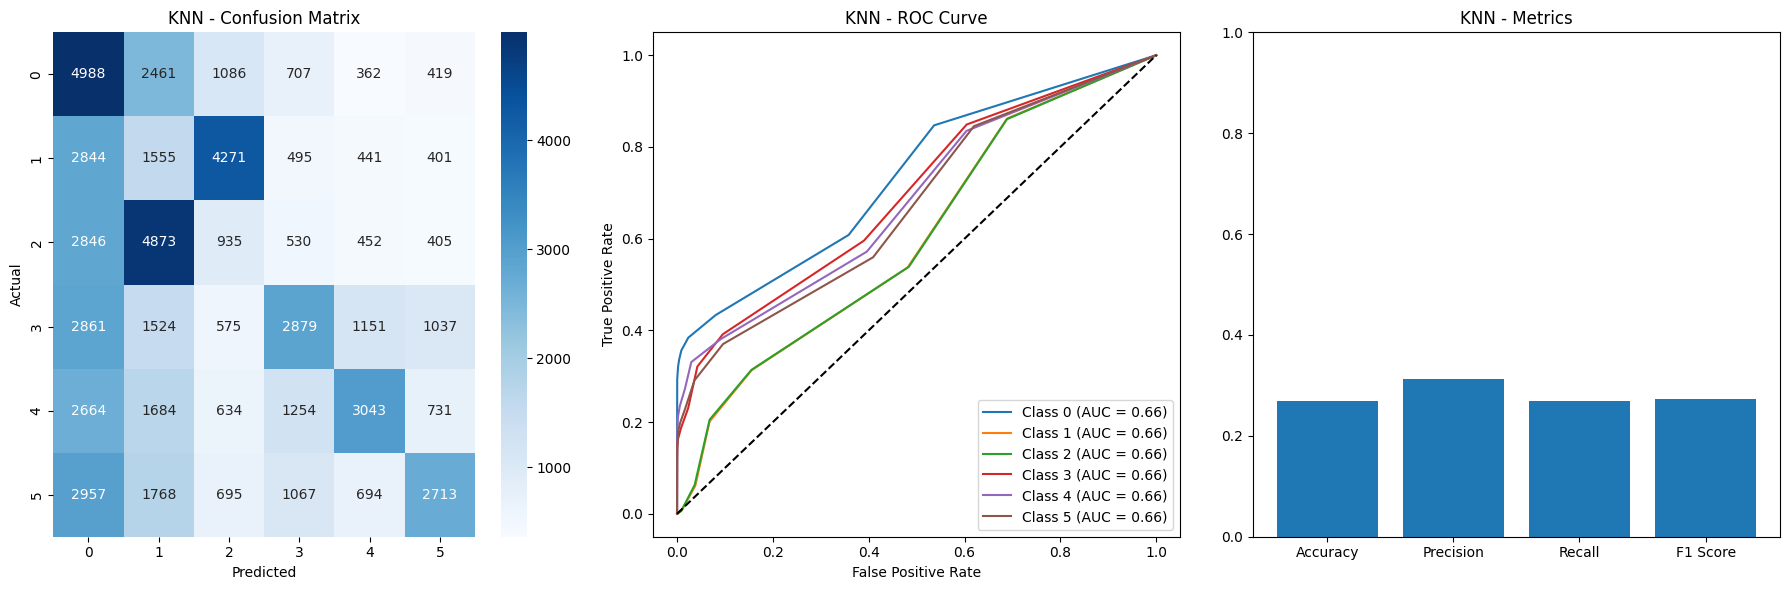

Model: LogisticRegression
Best Score: 0.1745887504079776
Best Params: {'C': 1, 'solver': 'lbfgs'}
Accuracy: 0.1749
Precision: 0.1299
Recall: 0.1749
F1 Score: 0.0965
ROC AUC: 0.5156
Training Time: 15.12 seconds
Prediction Time: 0.00 seconds




/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


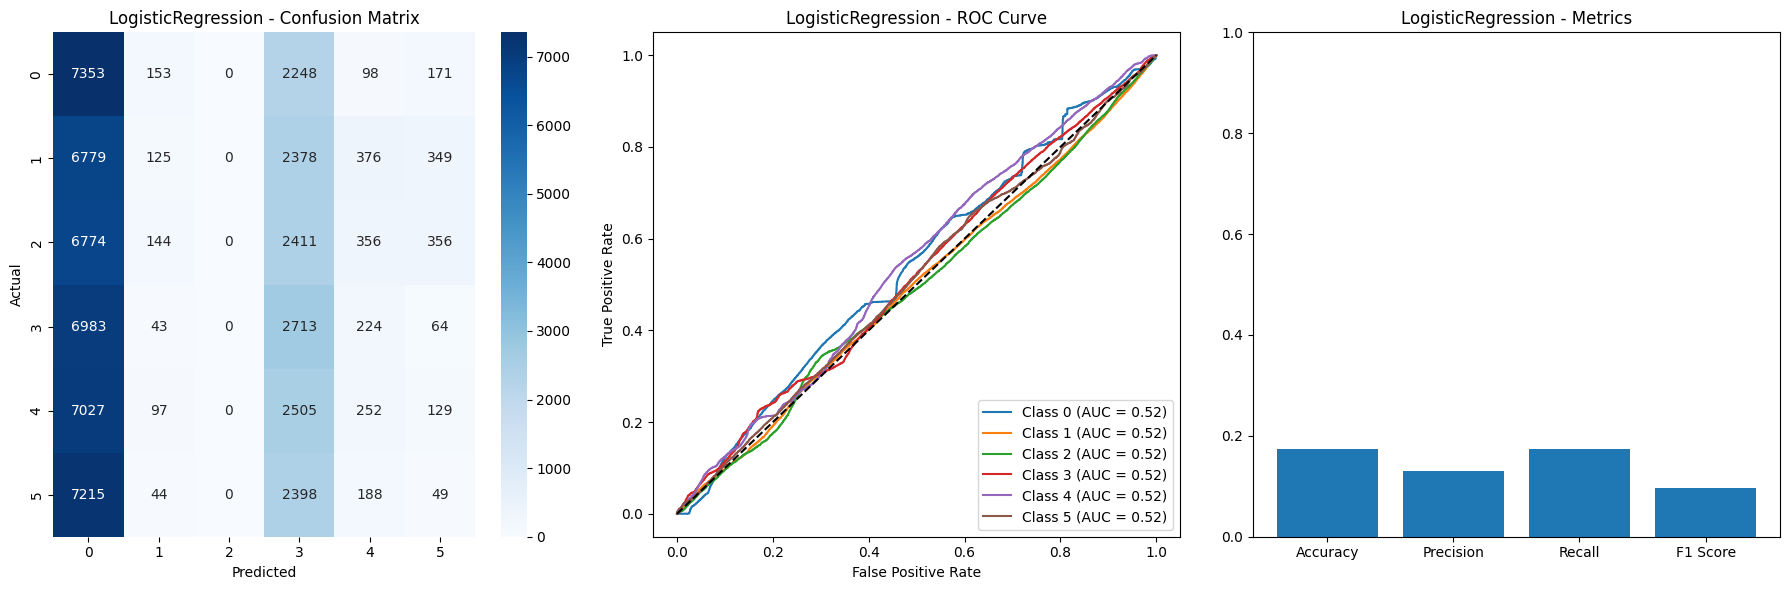

Model: DecisionTree
Best Score: 0.42504706177996293
Best Params: {'criterion': 'entropy', 'max_depth': 40}
Accuracy: 0.4304
Precision: 0.4583
Recall: 0.4304
F1 Score: 0.4366
ROC AUC: 0.7608
Training Time: 24.90 seconds
Prediction Time: 0.02 seconds




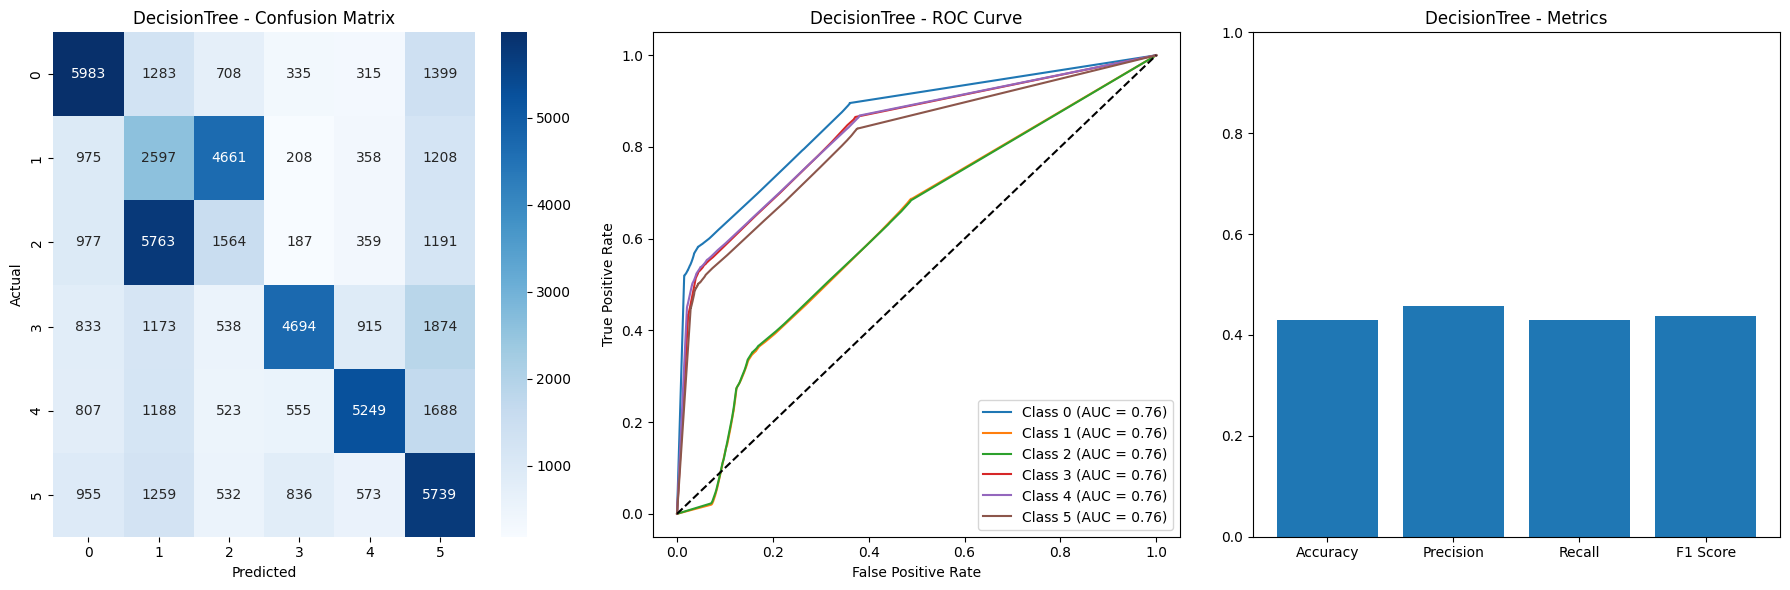

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Model: RandomForest
Best Score: 0.37708952799594453
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 200}
Accuracy: 0.3778
Precision: 0.3828
Recall: 0.3778
F1 Score: 0.3713
ROC AUC: 0.7762
Training Time: 1837.14 seconds
Prediction Time: 1.19 seconds




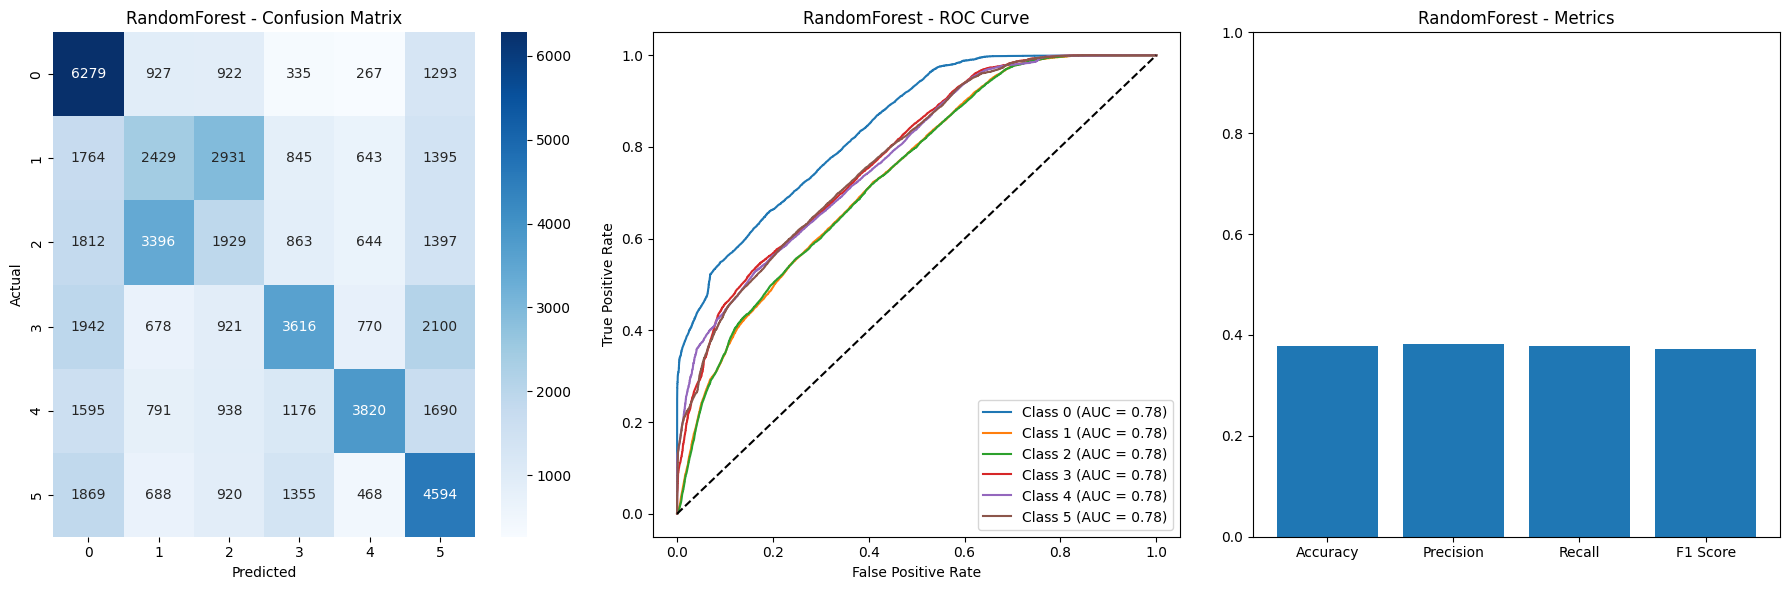

Model: XGBoost
Best Score: 0.4312053134309702
Best Params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 50}
Accuracy: 0.4261
Precision: 0.4210
Recall: 0.4261
F1 Score: 0.4202
ROC AUC: 0.8397
Training Time: 381.88 seconds
Prediction Time: 0.16 seconds




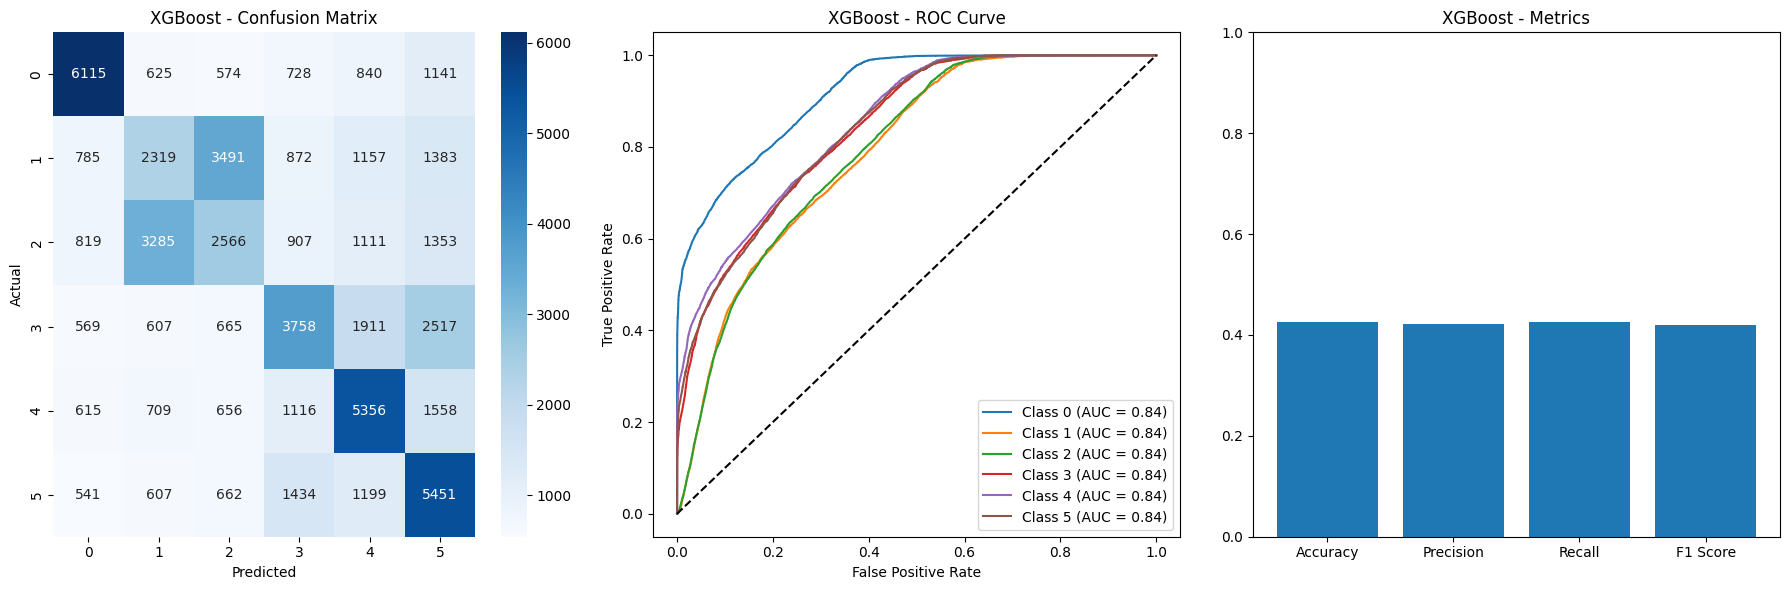

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Model: CatBoost
Best Score: 0.43333860423046744
Best Params: {'depth': 8, 'iterations': 300, 'learning_rate': 0.2}
Accuracy: 0.4328
Precision: 0.4228
Recall: 0.4328
F1 Score: 0.4268
ROC AUC: 0.8438
Training Time: 1376.15 seconds
Prediction Time: 0.02 seconds




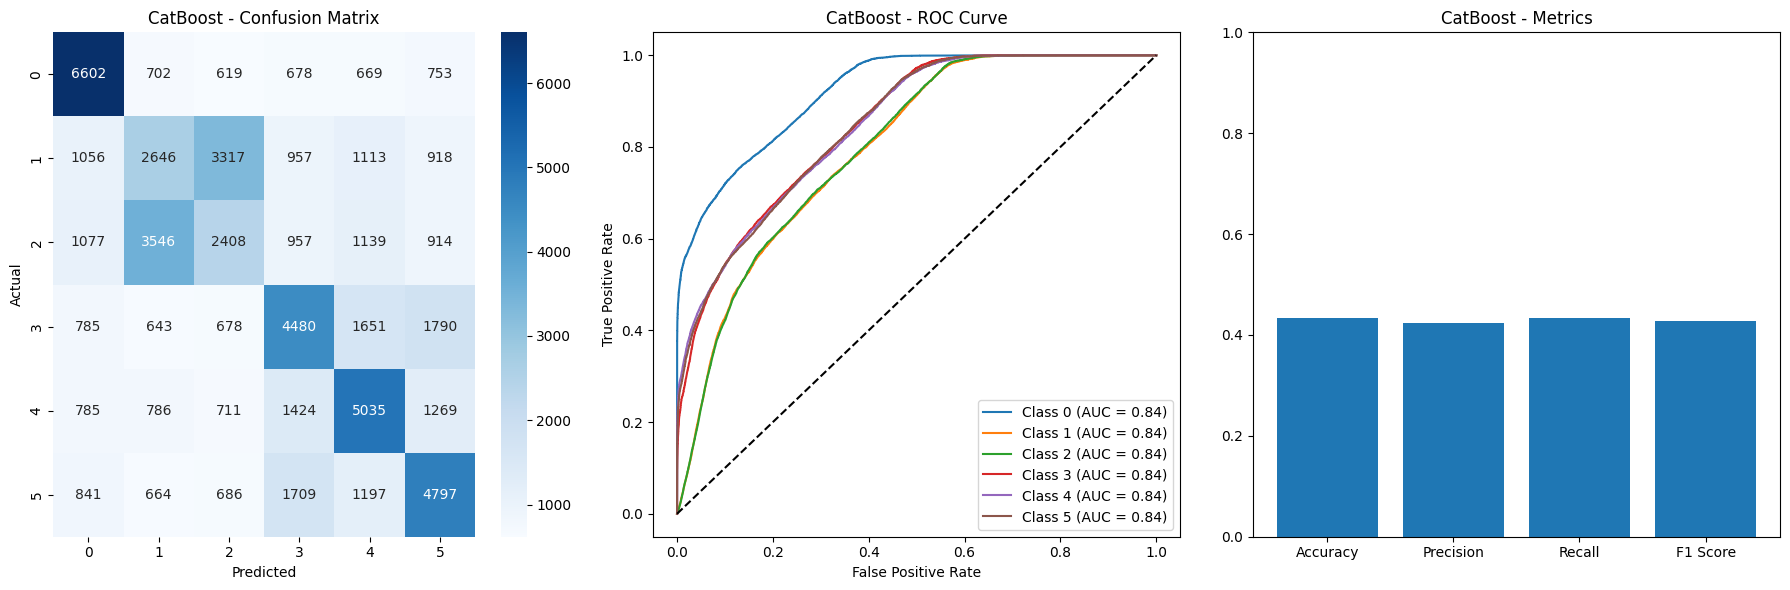

Summary of Results:
Model: KNN
Best Score: 0.29467424871356845
Best Params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Accuracy: 0.2685
Precision: 0.3117
Recall: 0.2685
F1 Score: 0.2729
ROC AUC: 0.6646
Training Time: 27.61 seconds
Prediction Time: 2.51 seconds


Model: LogisticRegression
Best Score: 0.1745887504079776
Best Params: {'C': 1, 'solver': 'lbfgs'}
Accuracy: 0.1749
Precision: 0.1299
Recall: 0.1749
F1 Score: 0.0965
ROC AUC: 0.5156
Training Time: 15.12 seconds
Prediction Time: 0.00 seconds


Model: DecisionTree
Best Score: 0.42504706177996293
Best Params: {'criterion': 'entropy', 'max_depth': 40}
Accuracy: 0.4304
Precision: 0.4583
Recall: 0.4304
F1 Score: 0.4366
ROC AUC: 0.7608
Training Time: 24.90 seconds
Prediction Time: 0.02 seconds


Model: RandomForest
Best Score: 0.37708952799594453
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 200}
Accuracy: 0.3778
Precision: 0.3828
Recall: 0.3778
F1 Score: 0.3713
ROC AUC: 0.7762
Training Tim

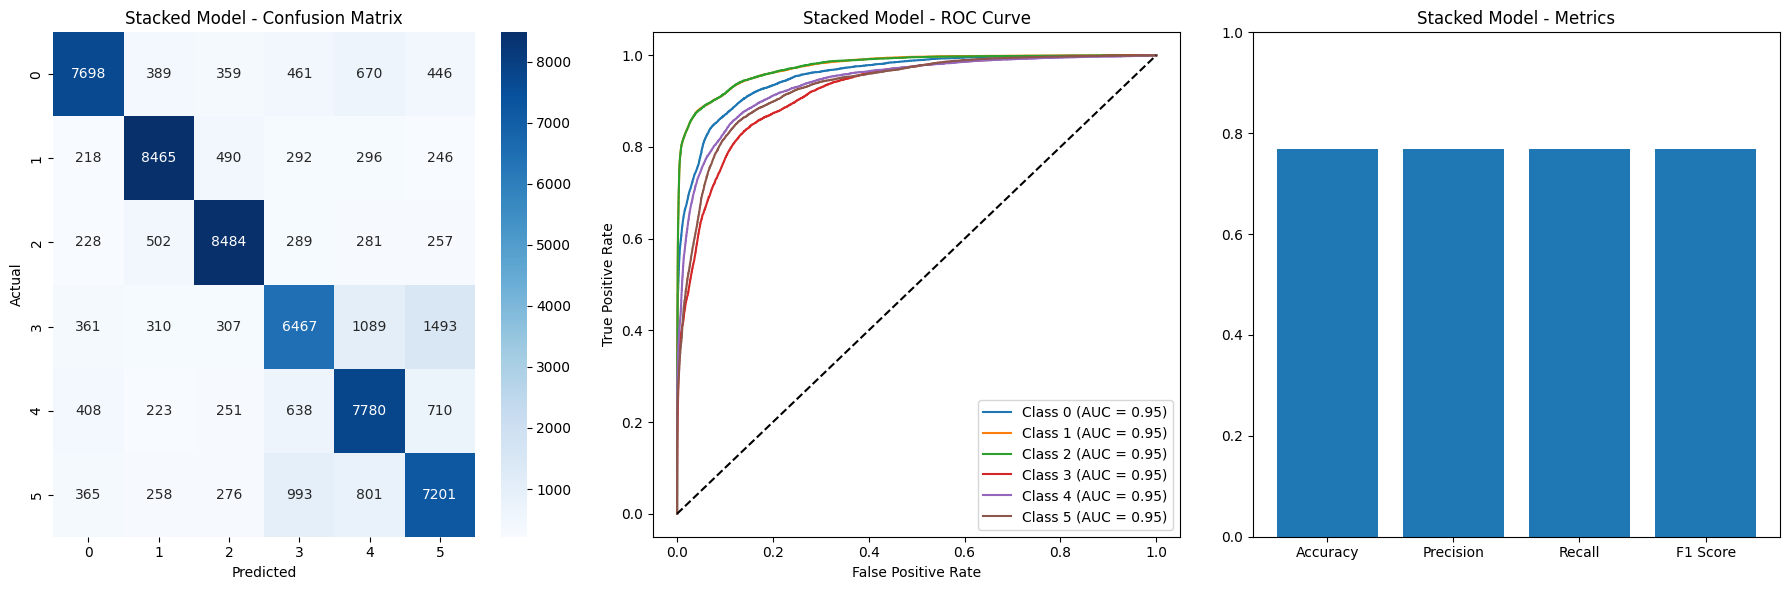

In [3]:
import numpy as np
from sklearn.utils import shuffle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier
import time



# Load dataset
df = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Forester/attack-free-1.csv', delimiter=',')
df['datetime'] = df['timestamp']
df['arbitration_id'] = df['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
df['data_field'] = df['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
df['attack'] = 0
df = df.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

ddos = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Forester/DoS-1.csv', delimiter=',')
ddos['datetime'] = ddos['timestamp']
ddos['arbitration_id'] = ddos['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
ddos['data_field'] = ddos['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
ddos['attack'] = 1
ddos = ddos.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

dfuzzy = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Forester/fuzzing-1.csv', delimiter=',')
dfuzzy['datetime'] = dfuzzy['timestamp']
dfuzzy['arbitration_id'] = dfuzzy['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dfuzzy['data_field'] = dfuzzy['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dfuzzy['attack'] = 2
dfuzzy = dfuzzy.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

dgear = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Forester/force-neutral-1.csv', delimiter=',')
dgear['datetime'] = dgear['timestamp']
dgear['arbitration_id'] = dgear['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dgear['data_field'] = dgear['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dgear['attack'] = 3
dgear = dgear.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

dspeed = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Forester/speed-1.csv', delimiter=',')
dspeed['datetime'] = dspeed['timestamp']
dspeed['arbitration_id'] = dspeed['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dspeed['data_field'] = dspeed['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dspeed['attack'] = 4
dspeed = dspeed.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

dstand = pd.read_csv('/content/drive/MyDrive/CAN_Research/CANData/CAND/Forester/standstill-1.csv', delimiter=',')
dstand['datetime'] = dstand['timestamp']
dstand['arbitration_id'] = dstand['arbitration_id'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dstand['data_field'] = dstand['data_field'].astype(str).dropna().apply(lambda x: float.fromhex(x))
dstand['attack'] = 5
dstand = dstand.loc[:50000, ['datetime','arbitration_id', 'data_field', 'attack']]

# Feature and label extraction
data = pd.concat([df, ddos, dfuzzy, dgear, dspeed, dstand])
data = shuffle(data)

X = data[['datetime','arbitration_id', 'data_field']]
y = data['attack']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models and their hyperparameters for GridSearchCV
models = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, multi_class='ovr'),
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],
            'solver': ['lbfgs', 'liblinear']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 10, 20, 30, 40, 50]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [10, 50, 100, 200],
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 10, 20, 30, 40, 50]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7, 9]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(verbose=0),
        'params': {
            'iterations': [100, 200, 300],
            'learning_rate': [0.01, 0.1, 0.2],
            'depth': [4, 6, 8]
        }
    }
}

# Perform GridSearchCV with K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for model_name, mp in models.items():
    start_time = time.time()
    clf = GridSearchCV(mp['model'], mp['params'], cv=kf, scoring='accuracy', n_jobs=-1)
    clf.fit(X_train_scaled, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    best_model = clf.best_estimator_

    print(f"Model: {model_name}")
    print(f"Best Score: {clf.best_score_}")
    print(f"Best Params: {clf.best_params_}")

    # Predict and calculate metrics
    start_time = time.time()
    y_pred = best_model.predict(X_test_scaled)
    end_time = time.time()
    prediction_time = end_time - start_time
    if hasattr(best_model, "predict_proba"):
        y_pred_prob = best_model.predict_proba(X_test_scaled)
    else:
        y_pred_prob = best_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Prediction Time: {prediction_time:.2f} seconds")
    print("\n")

    # Plot confusion matrix and ROC curve
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues')
    ax[0].set_title(f'{model_name} - Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # ROC Curve
    for i in range(len(set(y_test))):
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, i], pos_label=i)
        ax[1].plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_title(f'{model_name} - ROC Curve')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend(loc='lower right')

    # Bar plot for metrics
    metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
    ax[2].bar(metrics.keys(), metrics.values())
    ax[2].set_ylim(0, 1)
    ax[2].set_title(f'{model_name} - Metrics')

    plt.tight_layout()
    plt.show()

    results[model_name] = {
        'best_score': clf.best_score_,
        'best_params': clf.best_params_,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'training_time': training_time,
        'prediction_time': prediction_time
    }

# Print summary of results
print("Summary of Results:")
for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"Best Score: {result['best_score']}")
    print(f"Best Params: {result['best_params']}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall: {result['recall']:.4f}")
    print(f"F1 Score: {result['f1_score']:.4f}")
    print(f"ROC AUC: {result['roc_auc']:.4f}")
    print(f"Training Time: {result['training_time']:.2f} seconds")
    print(f"Prediction Time: {result['prediction_time']:.2f} seconds")
    print("\n")

# Define base models
base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')),
    ('decision_tree', DecisionTreeClassifier(criterion='gini', max_depth=20)),
    ('random_forest', RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=20)),
    ('xgboost', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='mlogloss')),
    ('catboost', CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=0))
]

# Define meta-learner
meta_learner = LogisticRegression(multi_class='ovr', max_iter=1000)

# Define stacking classifier
stacked_model = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)

# Train stacking model
start_time = time.time()
stacked_model.fit(X_train_scaled, y_train)
end_time = time.time()
training_time = end_time - start_time

# Predict and calculate metrics
start_time = time.time()
y_pred = stacked_model.predict(X_test_scaled)
end_time = time.time()
prediction_time = end_time - start_time
y_pred_prob = stacked_model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')

print(f"Stacked Model Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.2f} seconds")

# Plot confusion matrix and ROC curve
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[0].set_title('Stacked Model - Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve
for i in range(len(set(y_test))):
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, i], pos_label=i)
    ax[1].plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Stacked Model - ROC Curve')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].legend(loc='lower right')

# Bar plot for metrics
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}
ax[2].bar(metrics.keys(), metrics.values())
ax[2].set_ylim(0, 1)
ax[2].set_title('Stacked Model - Metrics')

plt.tight_layout()
plt.show()
